In [18]:
# ====== Robust Preprocess (fixed feature-name mismatch + sparse handling) ======
# Paste into a NEW cell and run.
import pandas as pd, numpy as np, re, os
from pathlib import Path
from pandas.api.types import is_datetime64_any_dtype
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# CONFIG (adjust if needed)
FILEPATH = r"C:\Users\Cindy\Downloads\retail_store_inventory.csv"
WINSOR_Q = (0.01, 0.99)
ONEHOT_MAX_UNIQUE = 12
SCOPE_REGION = "North"
SCOPE_CATEGORY = "Groceries"
SAVE_TO_CWD = True
SAVE_TO_DOWNLOADS = True

# 1) load
def try_find(path_hint=None):
    cand = []
    if path_hint: cand.append(Path(path_hint))
    cand += [Path.cwd()/"retail_store_inventory.csv", Path.home()/ "Downloads"/"retail_store_inventory.csv"]
    for p in Path.cwd().glob("*.csv"):
        if "retail" in p.name.lower(): cand.append(p)
    for p in cand:
        if p and p.exists(): return p
    return None
csv_p = try_find(FILEPATH)
if csv_p is None:
    raise FileNotFoundError("CSV not found. Put it in cwd or Downloads or adjust FILEPATH.")
print("Using", csv_p)
df_raw = pd.read_csv(csv_p)
print("Initial rows,cols:", df_raw.shape)

# 2) col mapping
col_map = {c.lower().strip(): c for c in df_raw.columns}
def find_col(*alts):
    for a in alts:
        if a and a.lower().strip() in col_map: return col_map[a.lower().strip()]
    return None
cols = {
    "date": find_col("date","transaction_date","day"),
    "store_id": find_col("store id","store_id","store"),
    "product_id": find_col("product id","product_id","product"),
    "inventory": find_col("inventory level","inventory","stock"),
    "units_sold": find_col("units sold","units_sold","sales"),
    "units_ordered": find_col("units ordered","units_ordered"),
    "demand_forecast": find_col("demand forecast","demand_forecast"),
    "price": find_col("price","unit_price"),
    "discount": find_col("discount","discount_pct","discount_rate"),
    "competitor_price": find_col("competitor pricing","competitor_price"),
    "category": find_col("category"),
    "region": find_col("region"),
    "weather": find_col("weather condition","weather"),
    "holiday": find_col("holiday/promotion","holiday","promotion"),
    "season": find_col("seasonality","season")
}
print("Resolved columns:", {k:v for k,v in cols.items() if v})

# 3) scope filter
df = df_raw.copy()
if cols.get("region") and cols["region"] in df.columns:
    before = len(df)
    df = df[df[cols["region"]].astype(str).str.strip().str.lower()==SCOPE_REGION.lower()].copy()
    print("Region filter:", before, "->", len(df))
if cols.get("category") and cols["category"] in df.columns:
    before = len(df)
    df = df[df[cols["category"]].astype(str).str.strip().str.lower()==SCOPE_CATEGORY.lower()].copy()
    print("Category filter:", before, "->", len(df))
print("Rows after scope:", len(df))

# 4) robust date parse (safe)
date_col = cols.get("date")
if date_col and date_col in df.columns:
    if date_col + "_orig" not in df.columns: df[date_col + "_orig"] = df[date_col]
    parsed = pd.to_datetime(df[date_col], errors="coerce")
    if parsed.isna().sum() > 0:
        # try cleaned parse
        def _clean(x):
            if pd.isna(x): return x
            s = str(x).strip()
            s = re.sub(r'\b(UTC|GMT)\b','',s,flags=re.I)
            s = re.sub(r'Z$','',s); s = re.sub(r'(\+|\-)\d{2}:\d{2}$','',s)
            return s
        parsed2 = pd.to_datetime(df[date_col].astype(str).map(_clean), errors="coerce")
        if parsed2.notna().sum() >= parsed.notna().sum(): parsed = parsed2
    # force numpy datetime64 array and assign by rebuilding DF if needed
    try:
        arr = np.array(parsed.tolist(), dtype='datetime64[ns]')
    except Exception:
        arr = pd.to_datetime(parsed.astype(str), errors='coerce').values.astype('datetime64[ns]')
    # rebuild DF to avoid mixed-object column
    df_rebuilt = df.copy()
    # create new DataFrame with date as first col to ensure dtype alignment
    other = {c: df_rebuilt[c].values for c in df_rebuilt.columns if c!=date_col}
    df2 = pd.DataFrame(other, index=df_rebuilt.index)
    df2.insert(0, date_col, pd.Series(arr, index=df_rebuilt.index))
    df = df2
    if not is_datetime64_any_dtype(df[date_col]):
        raise RuntimeError("Date column conversion failed.")
    df["day_of_week"] = df[date_col].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int).fillna(0).astype(int)
    df["month"] = df[date_col].dt.month
    print("Date parsed OK. NaT:", int(df[date_col].isna().sum()))
else:
    print("No date column found. Skipping date parse.")

# 5) winsorize + backup
numbers = [c for c in [cols.get("inventory"), cols.get("price"), cols.get("discount"),
                       cols.get("competitor_price"), cols.get("units_sold"),
                       cols.get("units_ordered"), cols.get("demand_forecast")] if c and c in df.columns]
for c in numbers:
    lo = df[c].quantile(WINSOR_Q[0]); hi = df[c].quantile(WINSOR_Q[1])
    if c + "_orig" not in df.columns: df[c + "_orig"] = df[c]
    df.loc[:, c] = df[c].clip(lower=lo, upper=hi)
    print("Winsorized", c)

# 6) sensible fills
if cols.get("discount") in df.columns: df.loc[:, cols["discount"]] = df[cols["discount"]].fillna(0)
if cols.get("holiday") in df.columns: df.loc[:, cols["holiday"]] = df[cols["holiday"]].fillna(0)
if cols.get("price") in df.columns: df.loc[:, cols["price"]] = df[cols["price"]].fillna(df[cols["price"]].median())
if cols.get("competitor_price") in df.columns: df.loc[:, cols["competitor_price"]] = df[cols["competitor_price"]].fillna(df[cols["competitor_price"]].median())

# 7) freq-encode ids
id_freqs=[]
for idc in [cols.get("store_id"), cols.get("product_id")]:
    if idc and idc in df.columns:
        freq = df[idc].value_counts(normalize=True)
        df[idc + "_freq"] = df[idc].map(freq).fillna(0)
        id_freqs.append(idc + "_freq")

# 8) low-card categories
cat_cols = [c for c in df.select_dtypes(include=['object','category']).columns if c not in [cols.get("store_id"), cols.get("product_id")]]
low_card = [c for c in cat_cols if df[c].nunique(dropna=True) <= ONEHOT_MAX_UNIQUE]
low_card = [c for c in low_card if not c.endswith("_orig")]
print("Low-card cat:", low_card)

# 9) pipelines
target_col = cols.get("units_sold") if cols.get("units_sold") in df.columns else None
numeric_feats = [c for c in df.select_dtypes(include=[np.number]).columns.tolist() if c != target_col]
numeric_feats = [c for c in numeric_feats if c not in [cols.get("store_id"), cols.get("product_id")]]

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])

ohe_kwargs = {"handle_unknown":"ignore"}
try:
    _ = OneHotEncoder(sparse_output=False, **ohe_kwargs)
    ohe_obj = OneHotEncoder(sparse_output=False, **ohe_kwargs)
except TypeError:
    ohe_obj = OneHotEncoder(sparse=False, **ohe_kwargs)

cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", ohe_obj)])

transformers=[]
if numeric_feats: transformers.append(("num", num_pipe, numeric_feats))
if low_card: transformers.append(("cat", cat_pipe, low_card))

pre = ColumnTransformer(transformers=transformers, remainder="passthrough", sparse_threshold=0)

# fit_transform
X = pre.fit_transform(df)

# ensure X is dense numpy array
if hasattr(X, "toarray"):
    X = X.toarray()

# Build feature names robustly and check length
feature_names = []
if numeric_feats: feature_names += numeric_feats
if low_card:
    ohe = pre.named_transformers_['cat'].named_steps['ohe']
    for i, c in enumerate(low_card):
        cats = list(ohe.categories_[i])
        feature_names += [f"{c}__{str(cat)}" for cat in cats]
# remainder columns in original order
remainder = [c for c in df.columns if c not in (numeric_feats + low_card)]
feature_names += remainder

# sanity check: lengths must match
if len(feature_names) != X.shape[1]:
    print("WARNING: feature_names length != X.shape[1]. Fixing by auto-generating names.")
    feature_names = [f"f_{i}" for i in range(X.shape[1])]

df_final = pd.DataFrame(X, columns=feature_names, index=df.index)

# attach target and original ids
if target_col: df_final[target_col] = df[target_col].values
for idc in [cols.get("store_id"), cols.get("product_id")]:
    if idc and idc in df.columns: df_final[idc] = df[idc].values

candidate = [c for c in df_final.columns if c not in {cols.get("store_id"), cols.get("product_id"), target_col}]
print("df_final shape:", df_final.shape, "candidate features:", len(candidate))

# save attempts
saved=[]
if SAVE_TO_CWD:
    out = Path.cwd()/ "retail_store_inventory_cleaned_final.csv"
    try:
        df_final.to_csv(out, index=False); saved.append(str(out))
    except Exception as e:
        print("Save cwd failed:", e)
if SAVE_TO_DOWNLOADS:
    out2 = Path.home()/ "Downloads"/ "retail_store_inventory_cleaned_final.csv"
    try:
        df_final.to_csv(out2, index=False); saved.append(str(out2))
    except Exception as e:
        print("Save downloads failed:", e)

print("Saved:", saved)
globals()['df_final']=df_final; globals()['df_clean']=df; globals()['candidate_features']=candidate; globals()['target_col']=target_col
print("Done. exported df_final, df_clean, candidate_features, target_col.")


Using /content/retail_store_inventory.csv
Initial rows,cols: (73100, 15)
Resolved columns: {'date': 'Date', 'store_id': 'Store ID', 'product_id': 'Product ID', 'inventory': 'Inventory Level', 'units_sold': 'Units Sold', 'units_ordered': 'Units Ordered', 'demand_forecast': 'Demand Forecast', 'price': 'Price', 'discount': 'Discount', 'competitor_price': 'Competitor Pricing', 'category': 'Category', 'region': 'Region', 'weather': 'Weather Condition', 'holiday': 'Holiday/Promotion', 'season': 'Seasonality'}
Region filter: 73100 -> 18228
Category filter: 18228 -> 3652
Rows after scope: 3652
Date parsed OK. NaT: 0
Winsorized Inventory Level
Winsorized Price
Winsorized Discount
Winsorized Competitor Pricing
Winsorized Units Sold
Winsorized Units Ordered
Winsorized Demand Forecast
Low-card cat: ['Category', 'Region', 'Weather Condition', 'Seasonality']


/tmp/ipython-input-262794597.py:117: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 55. 140.  22. ...  79.  80. 156.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, c] = df[c].clip(lower=lo, upper=hi)


df_final shape: (3652, 34) candidate features: 31
Save downloads failed: Cannot save file into a non-existent directory: '/root/Downloads'
Saved: ['/content/retail_store_inventory_cleaned_final.csv']
Done. exported df_final, df_clean, candidate_features, target_col.


EDA dataset shape: (3652, 28)


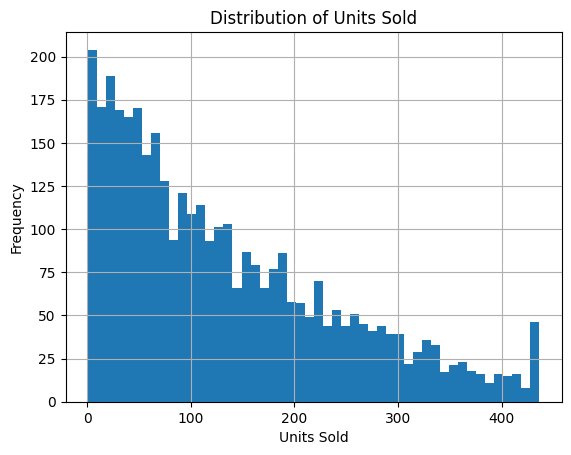

count    3652.000000
mean      133.764513
std       108.115317
min         1.000000
25%        45.000000
50%       106.000000
75%       200.000000
max       436.000000
Name: Units Sold, dtype: float64


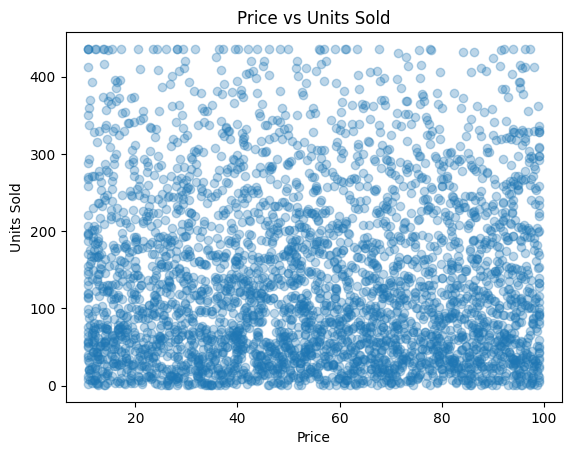

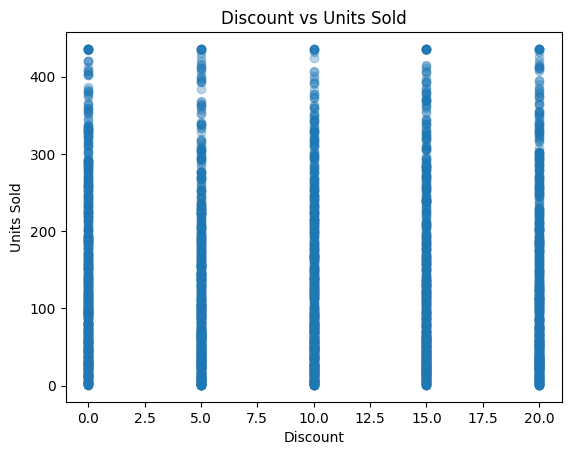

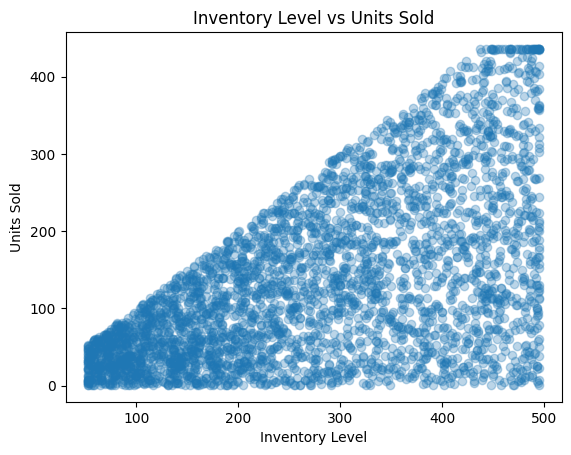

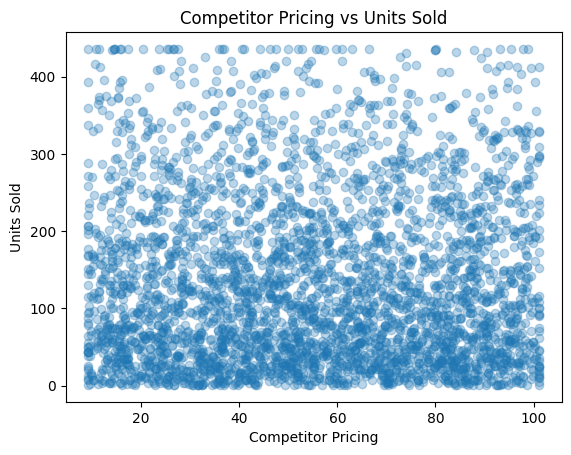


Average Units Sold by Holiday/Promotion
Holiday/Promotion
0    134.018172
1    133.513617
Name: Units Sold, dtype: float64


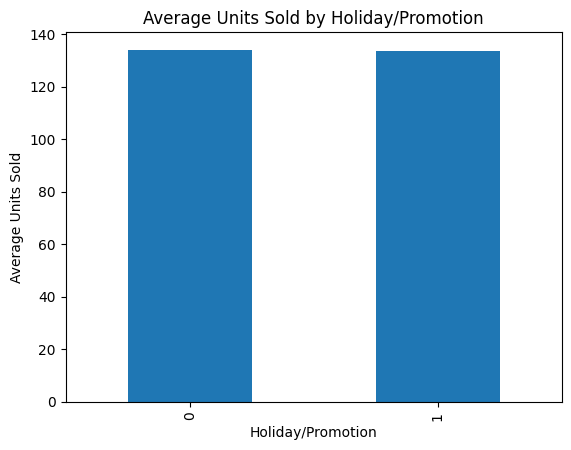


Average Units Sold by Weather Condition
Weather Condition
Cloudy    136.674234
Snowy     134.453057
Rainy     132.497354
Sunny     131.570330
Name: Units Sold, dtype: float64


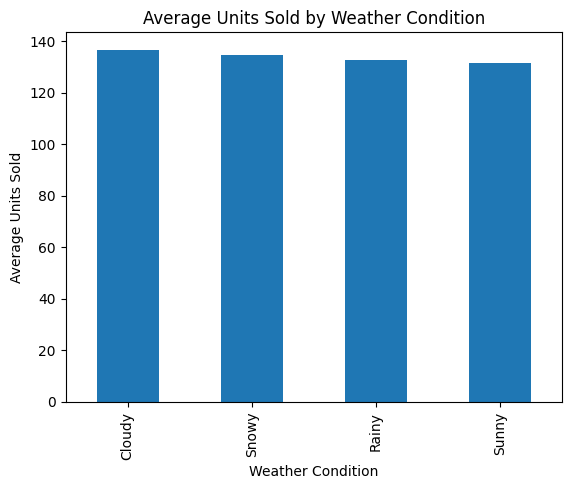


Average Units Sold by Seasonality
Seasonality
Autumn    135.926349
Winter    133.272196
Spring    133.091209
Summer    132.625813
Name: Units Sold, dtype: float64


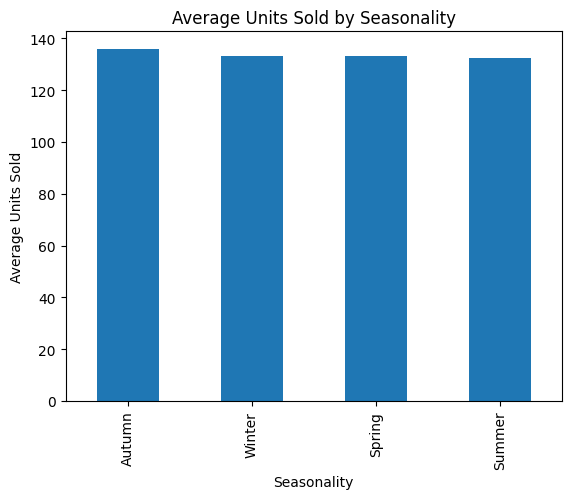


Average Units Sold by day_of_week
day_of_week
0    129.973881
1    139.387681
2    132.791075
3    129.785571
4    138.658153
5    127.842991
6    137.685606
Name: Units Sold, dtype: float64


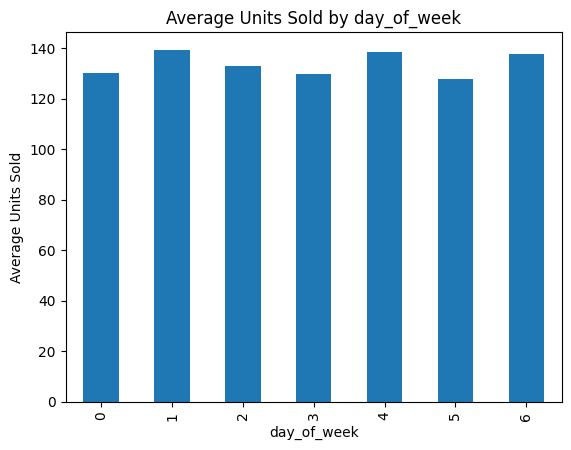


Average Units Sold by month
month
1     142.156977
2     132.784000
3     136.834286
4     133.651246
5     138.100295
6     128.200000
7     133.558528
8     135.478405
9     136.697987
10    125.521127
11    139.304348
12    121.538462
Name: Units Sold, dtype: float64


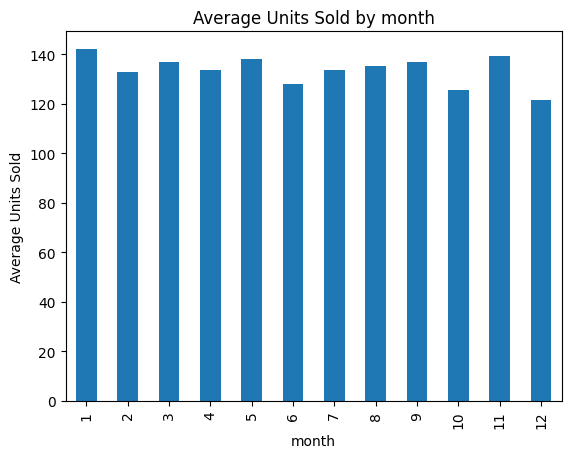

In [19]:
# =========================
# EDA: Exploratory Data Analysis
# =========================

import matplotlib.pyplot as plt
import pandas as pd

# 使用你 preprocessing 後的資料
if 'df_clean' in globals():
    df_eda = df_clean.copy()
else:
    raise RuntimeError("找不到 df_clean，請先完成 preprocessing。")

target = 'Units Sold'  # 你的 target

print("EDA dataset shape:", df_eda.shape)

# ---------- 1. Target distribution ----------
plt.figure()
df_eda[target].hist(bins=50)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

print(df_eda[target].describe())

# ---------- 2. Numeric vs Units Sold ----------
numeric_vars = [
    'Price',
    'Discount',
    'Inventory Level',
    'Competitor Pricing'
]

for var in numeric_vars:
    if var in df_eda.columns:
        plt.figure()
        plt.scatter(df_eda[var], df_eda[target], alpha=0.3)
        plt.xlabel(var)
        plt.ylabel("Units Sold")
        plt.title(f"{var} vs Units Sold")
        plt.show()

# ---------- 3. Categorical comparisons ----------
categorical_vars = [
    'Holiday/Promotion',
    'Weather Condition',
    'Seasonality'
]

for var in categorical_vars:
    if var in df_eda.columns:
        means = df_eda.groupby(var)[target].mean().sort_values(ascending=False)
        print(f"\nAverage Units Sold by {var}")
        print(means)

        plt.figure()
        means.plot(kind='bar')
        plt.title(f"Average Units Sold by {var}")
        plt.ylabel("Average Units Sold")
        plt.show()

# ---------- 4. Time features ----------
time_vars = ['day_of_week', 'month']

for var in time_vars:
    if var in df_eda.columns:
        means = df_eda.groupby(var)[target].mean()
        print(f"\nAverage Units Sold by {var}")
        print(means)

        plt.figure()
        means.plot(kind='bar')
        plt.title(f"Average Units Sold by {var}")
        plt.ylabel("Average Units Sold")
        plt.show()


Inventory EDA dataset shape: (3652, 28)


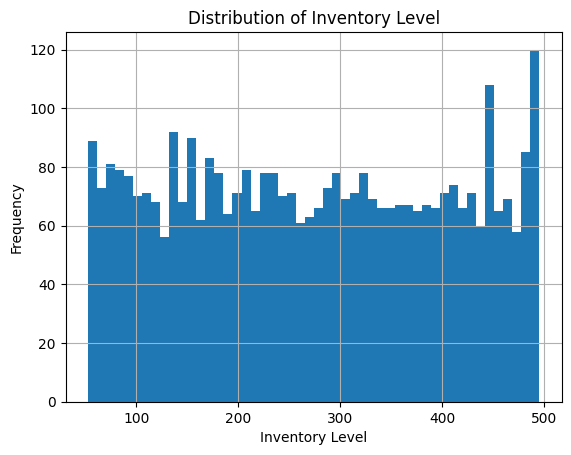


Inventory Level summary:
count    3652.000000
mean      273.758488
std       130.975985
min        53.000000
25%       159.000000
50%       272.000000
75%       388.250000
max       495.000000
Name: Inventory Level, dtype: float64


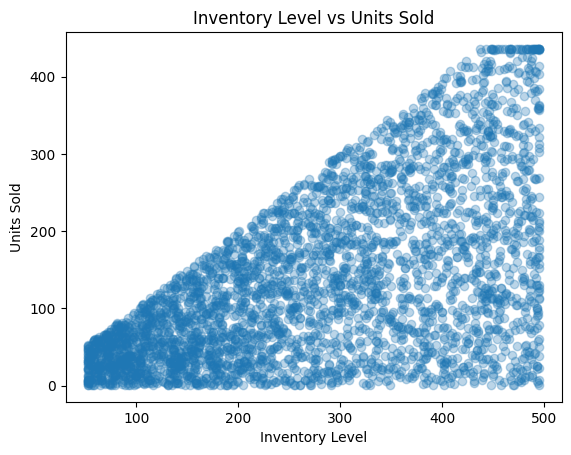


Correlation between Inventory Level and Units Sold:
                 Inventory Level  Units Sold
Inventory Level         1.000000    0.577601
Units Sold              0.577601    1.000000


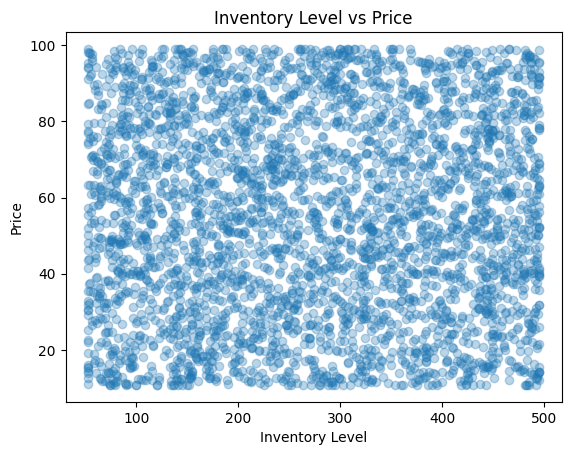

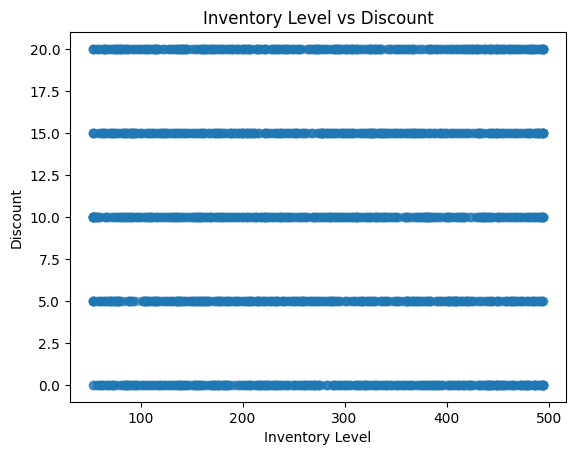


Average Inventory Level by Holiday/Promotion:
Holiday/Promotion
0    273.129405
1    274.380719
Name: Inventory Level, dtype: float64


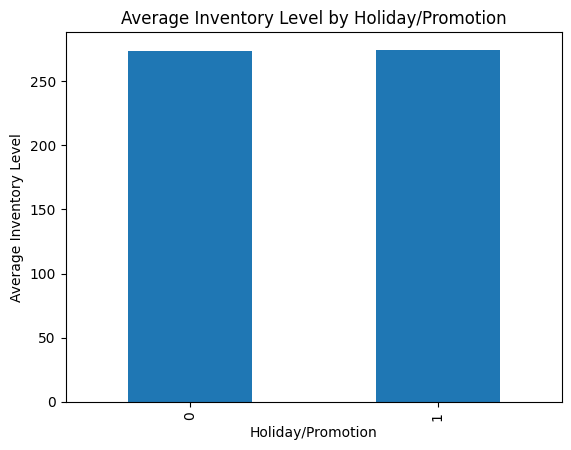


Average Inventory Level by Seasonality:
Seasonality
Spring    277.360440
Autumn    276.037344
Summer    271.556399
Winter    269.734813
Name: Inventory Level, dtype: float64


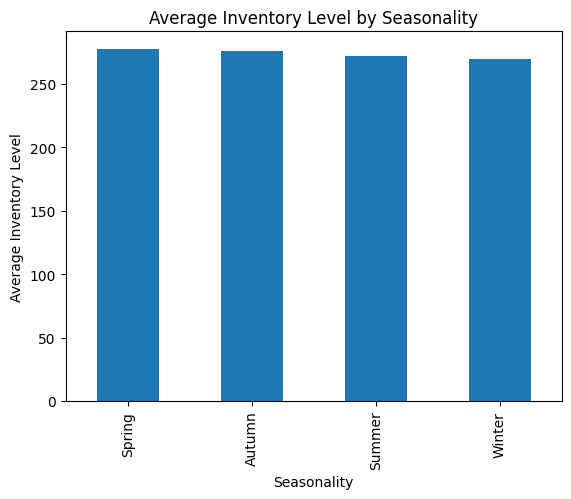


Average Inventory Level by Day of Week:
day_of_week
0    274.725746
1    273.932971
2    280.803245
3    263.370741
4    274.785855
5    269.351402
6    279.308712
Name: Inventory Level, dtype: float64


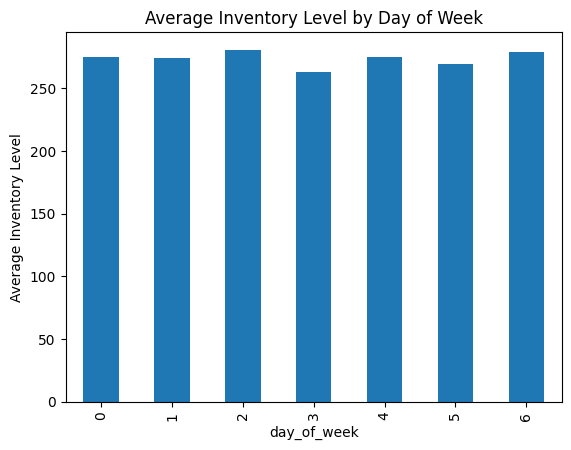

In [20]:
# =========================
# EDA: Inventory Level Analysis
# =========================

import matplotlib.pyplot as plt
import pandas as pd

# 使用 preprocessing 後、未編碼的資料
if 'df_clean' not in globals():
    raise RuntimeError("找不到 df_clean，請先完成 preprocessing。")

df_inv = df_clean.copy()

inv_col = 'Inventory Level'
target = 'Units Sold'

print("Inventory EDA dataset shape:", df_inv.shape)

# ---------- 1. Inventory Level distribution ----------
plt.figure()
df_inv[inv_col].hist(bins=50)
plt.title("Distribution of Inventory Level")
plt.xlabel("Inventory Level")
plt.ylabel("Frequency")
plt.show()

print("\nInventory Level summary:")
print(df_inv[inv_col].describe())

# ---------- 2. Inventory Level vs Units Sold ----------
plt.figure()
plt.scatter(df_inv[inv_col], df_inv[target], alpha=0.3)
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")
plt.title("Inventory Level vs Units Sold")
plt.show()

print("\nCorrelation between Inventory Level and Units Sold:")
print(df_inv[[inv_col, target]].corr())

# ---------- 3. Inventory Level vs Price ----------
if 'Price' in df_inv.columns:
    plt.figure()
    plt.scatter(df_inv[inv_col], df_inv['Price'], alpha=0.3)
    plt.xlabel("Inventory Level")
    plt.ylabel("Price")
    plt.title("Inventory Level vs Price")
    plt.show()

# ---------- 4. Inventory Level vs Discount ----------
if 'Discount' in df_inv.columns:
    plt.figure()
    plt.scatter(df_inv[inv_col], df_inv['Discount'], alpha=0.3)
    plt.xlabel("Inventory Level")
    plt.ylabel("Discount")
    plt.title("Inventory Level vs Discount")
    plt.show()

# ---------- 5. Inventory Level by Holiday ----------
if 'Holiday/Promotion' in df_inv.columns:
    means = df_inv.groupby('Holiday/Promotion')[inv_col].mean()
    print("\nAverage Inventory Level by Holiday/Promotion:")
    print(means)

    plt.figure()
    means.plot(kind='bar')
    plt.ylabel("Average Inventory Level")
    plt.title("Average Inventory Level by Holiday/Promotion")
    plt.show()

# ---------- 6. Inventory Level by Season ----------
if 'Seasonality' in df_inv.columns:
    means = df_inv.groupby('Seasonality')[inv_col].mean().sort_values(ascending=False)
    print("\nAverage Inventory Level by Seasonality:")
    print(means)

    plt.figure()
    means.plot(kind='bar')
    plt.ylabel("Average Inventory Level")
    plt.title("Average Inventory Level by Seasonality")
    plt.show()

# ---------- 7. Inventory Level vs Time ----------
if 'day_of_week' in df_inv.columns:
    means = df_inv.groupby('day_of_week')[inv_col].mean()
    print("\nAverage Inventory Level by Day of Week:")
    print(means)

    plt.figure()
    means.plot(kind='bar')
    plt.ylabel("Average Inventory Level")
    plt.title("Average Inventory Level by Day of Week")
    plt.show()


Original candidate features: 31
Initial datetime cols detected: ['Date']
Initial other non-numeric/object cols detected: ['Inventory Level', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing', 'day_of_week', 'is_weekend', 'month', 'Inventory Level_orig', 'Price_orig', 'Discount_orig', 'Competitor Pricing_orig', 'Units Sold_orig', 'Units Ordered_orig', 'Demand Forecast_orig', 'Store ID_freq', 'Product ID_freq', 'Category__Groceries', 'Region__North', 'Weather Condition__Cloudy', 'Weather Condition__Rainy', 'Weather Condition__Snowy', 'Weather Condition__Sunny', 'Seasonality__Autumn', 'Seasonality__Spring', 'Seasonality__Summer', 'Seasonality__Winter', 'Date_orig']
Converted datetime Date -> int (seconds).
Coerced Inventory Level to numeric (kept). Non-null fraction: 1.00
Coerced Units Ordered to numeric (kept). Non-null fraction: 1.00
Coerced Demand Forecast to numeric (kept). Non-null fraction: 1.00
Coerced Price to numeric (kept). Non-nu

/tmp/ipython-input-2515626268.py:44: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1640995200 1640995200 1640995200 ... 1704067200 1704067200 1704067200]' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  dfm.loc[:, c] = dfm[c].astype('int64') // 10**9



Baseline RandomForest Results: RMSE=185.562, MAE=166.348

Top 20 features by importance:
Date    1.0
dtype: float64


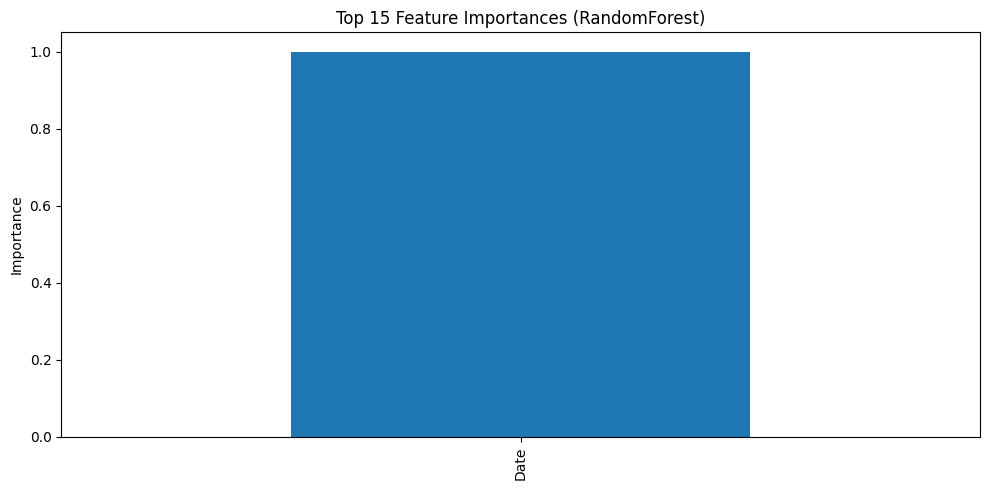

,date,actual,predicted
58315,1691366400,97.0,285.277327
58316,1691366400,324.0,285.277327
58360,1691366400,112.0,285.277327
58367,1691366400,142.0,285.277327
58369,1691366400,55.0,285.277327
58386,1691366400,43.0,285.277327
58391,1691366400,75.0,285.277327
58409,1691452800,420.0,285.277327
58422,1691452800,198.0,285.277327
58449,1691452800,102.0,285.277327


In [21]:
# ===== Robust baseline (fixed fallback for empty numeric features) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 確認必要變數存在
if 'df_final' not in globals() or 'candidate_features' not in globals() or 'target_col' not in globals():
    raise RuntimeError("找不到 df_final / candidate_features / target_col。請先執行 preprocess cell。")

dfm = df_final.copy()
raw_features = list(candidate_features)  # copy
target = target_col

print("Original candidate features:", len(raw_features))

# 1) detect datetime & non-numeric columns
datetime_cols = []
non_numeric = []
for c in raw_features:
    if c not in dfm.columns:
        non_numeric.append(c)
        continue
    dt = dfm[c].dtype
    if np.issubdtype(dt, np.datetime64):
        datetime_cols.append(c)
    elif np.issubdtype(dt, np.number):
        # numeric ok
        pass
    elif pd.api.types.is_bool_dtype(dt):
        pass
    else:
        non_numeric.append(c)

print("Initial datetime cols detected:", datetime_cols)
print("Initial other non-numeric/object cols detected:", non_numeric)

# 2) Convert datetime cols -> int (seconds since epoch), use astype (no .view)
for c in datetime_cols:
    try:
        # ensure it's datetime
        dfm.loc[:, c] = pd.to_datetime(dfm[c], errors='coerce')
        dfm.loc[:, c] = dfm[c].astype('int64') // 10**9
        print(f"Converted datetime {c} -> int (seconds).")
    except Exception as e:
        print(f"Failed to convert datetime column {c}: {e}")

# 3) Try to coerce remaining non-numeric to numeric
coerced_ok = []
coerced_failed = []
for c in list(non_numeric):
    if c not in dfm.columns:
        coerced_failed.append(c); continue
    coerced = pd.to_numeric(dfm[c], errors='coerce')
    pct_nonnull = coerced.notna().mean()
    if pct_nonnull >= 0.7:
        dfm.loc[:, c] = coerced
        coerced_ok.append((c, pct_nonnull))
        print(f"Coerced {c} to numeric (kept). Non-null fraction: {pct_nonnull:.2f}")
    else:
        coerced_failed.append((c, pct_nonnull))
        # we will not include this in features (but keep column in dfm)
        print(f"Will NOT use {c} (coercion produced non-null fraction {pct_nonnull:.2f})")

# 4) Build final numeric feature list; fallback to df.select_dtypes if empty
features_numeric = [c for c in raw_features if c in dfm.columns and np.issubdtype(dfm[c].dtype, np.number)]

if len(features_numeric) == 0:
    # fallback: grab any numeric columns in dfm except target and ids
    all_numeric = dfm.select_dtypes(include=[np.number]).columns.tolist()
    exclude = {target, 'Store ID', 'Product ID', cols.get('store_id'), cols.get('product_id')}
    features_numeric = [c for c in all_numeric if c not in exclude]
    print("Fallback: derived numeric features from df_final.select_dtypes")

print("Final numeric features count:", len(features_numeric))
print("Example features (first 20):", features_numeric[:20])

if len(features_numeric) == 0:
    raise RuntimeError("無法找到任何可用的數值特徵。請回到 preprocess 檢查 candidate_features 與 df_final 的欄位型別。")

# 5) remove columns with too many NaNs (>30%)
removed_for_nan = []
for c in list(features_numeric):
    if dfm[c].isna().mean() > 0.3:
        features_numeric.remove(c)
        removed_for_nan.append(c)
        print(f"Removed {c} due >30% missing")

print("Removed for NaN:", removed_for_nan)
print("Final features count after NaN filter:", len(features_numeric))

# 6) Ensure target numeric & no NaNs
if dfm[target].isna().any():
    raise RuntimeError(f"Target {target} has NaNs. Please fix.")
if not np.issubdtype(dfm[target].dtype, np.number):
    dfm[target] = pd.to_numeric(dfm[target], errors='raise')

# 7) Sort by Date if exists, else index
date_col = 'Date' if 'Date' in dfm.columns else None
if date_col:
    dfm = dfm.sort_values(date_col)
else:
    dfm = dfm.sort_index()

# 8) Train/test split (time-based)
n = len(dfm); split = int(n * 0.8)
train = dfm.iloc[:split]; test = dfm.iloc[split:]
X_train = train[features_numeric].astype(float).fillna(0.0)
y_train = train[target].astype(float)
X_test  = test[features_numeric].astype(float).fillna(0.0)
y_test  = test[target].astype(float)

print("Train rows:", X_train.shape[0], "Test rows:", X_test.shape[0], "Features:", X_train.shape[1])

# 9) Fit RandomForest
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 10) Predict + evaluate
preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae  = mean_absolute_error(y_test, preds)
print(f"\nBaseline RandomForest Results: RMSE={rmse:.3f}, MAE={mae:.3f}")

# 11) Feature importance
importances = pd.Series(model.feature_importances_, index=features_numeric).sort_values(ascending=False)
print("\nTop 20 features by importance:")
print(importances.head(20))

plt.figure(figsize=(10,5))
importances.head(15).plot(kind='bar')
plt.title("Top 15 Feature Importances (RandomForest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# 12) show actual vs predicted sample
if date_col:
    display(pd.DataFrame({
        "date": test[date_col],
        "actual": y_test.values,
        "predicted": preds
    }).head(10))
else:
    display(pd.DataFrame({
        "actual": y_test.values,
        "predicted": preds
    }).head(10))


In [22]:
# =========================
# Baseline: Predict Inventory Level using Date only
# =========================

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 使用 preprocessing 後的資料
if 'df_clean' not in globals():
    raise RuntimeError("找不到 df_clean，請先完成 preprocessing。")

df_inv_model = df_clean.copy()

target = 'Inventory Level'

# 確認需要的時間特徵存在
required_time_features = ['day_of_week', 'is_weekend', 'month']
for f in required_time_features:
    if f not in df_inv_model.columns:
        raise RuntimeError(f"缺少時間特徵 {f}，請先完成 date preprocessing。")

features = required_time_features

print("Baseline Inventory model")
print("Target:", target)
print("Features:", features)

# ---------- 1. Time-based split ----------
date_col = 'Date'
df_inv_model = df_inv_model.sort_values(date_col)

split_idx = int(len(df_inv_model) * 0.8)
train = df_inv_model.iloc[:split_idx]
test = df_inv_model.iloc[split_idx:]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print("Train rows:", len(train))
print("Test rows:", len(test))

# ---------- 2. Train baseline model ----------
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ---------- 3. Evaluation ----------
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)

print(f"\nDate-only Inventory Baseline Results")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")

# ---------- 4. Feature importance ----------
importances = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature importance (Date-only Inventory baseline):")
print(importances)

# ---------- 5. Sample predictions ----------
sample = pd.DataFrame({
    'Date': test['Date'],
    'Actual Inventory': y_test,
    'Predicted Inventory': preds
}).head(10)

print("\nSample predictions:")
display(sample)


Baseline Inventory model
Target: Inventory Level
Features: ['day_of_week', 'is_weekend', 'month']
Train rows: 2921
Test rows: 731

Date-only Inventory Baseline Results
RMSE: 130.39
MAE : 111.11

Feature importance (Date-only Inventory baseline):
month          0.562735
day_of_week    0.399956
is_weekend     0.037309
dtype: float64

Sample predictions:


,Date,Actual Inventory,Predicted Inventory
58386,2023-08-07,232,290.998646
58369,2023-08-07,410,290.998646
58367,2023-08-07,294,290.998646
58313,2023-08-07,420,290.998646
58316,2023-08-07,398,290.998646
58315,2023-08-07,380,290.998646
58360,2023-08-07,139,290.998646
58409,2023-08-08,443,233.491247
58422,2023-08-08,463,233.491247
58449,2023-08-08,188,233.491247


12/23 Session – 3-Minute Summary
Project

Daily Product Demand Forecasting for Inventory Management

1. Dataset Structure & Scope

Each row represents Date × Store × Product.
The target variable is Units Sold, which represents daily realized demand.

Numeric variables: Inventory Level, Units Sold, Price, Discount, Competitor Pricing

Categorical variables: Category, Region, Weather Condition, Holiday/Promotion, Seasonality

Time variable: Date

Identifiers: Store ID, Product ID

The analysis was scoped to Region = North and Category = Groceries, resulting in 3,652 observations.

2. Data Quality Check

No missing values were found in the scoped dataset.

Logical checks confirmed Units Sold ≤ Inventory Level and no negative values.

Price and Discount values fall within reasonable ranges.

No duplicate rows were identified.

Overall, the dataset is clean and internally consistent.

3. Outliers & Missing Values

Outliers were observed in Units Sold, Price, and Discount.

We applied winsorization at the 1st and 99th percentiles to cap extreme values while preserving all observations.

Although no missing values were present, we defined clear handling rules:

Price and Competitor Pricing → median

Discount and Holiday → filled with 0

Categorical variables → mode if missing in future data

4. Feature Decisions

Selected features:

Inventory Level

Price

Discount

Competitor Pricing

Weather Condition

Holiday/Promotion

Seasonality

Date-derived features: Day of Week, Month

Excluded features:

Units Ordered (operational decision outcome)

Demand Forecast (baseline comparison only)

Store ID / Product ID (identifiers only)

This avoids information leakage and ensures the model learns true demand patterns.

5. Encoding & Readiness for Modeling

Categorical variables will be one-hot encoded.

Date features (Day of Week, Month) are included.

Numeric features were prepared with scaling to support multiple model types.

No modeling was performed in this session; the dataset is now model-ready.

Final Wrap-Up

By the end of this session:

We finalized a clean dataset within the agreed scope.

Agreed on consistent outlier and missing value handling rules.

Confirmed the final feature set and preprocessing assumptions.

Next session will focus on baseline demand prediction, model training, RMSE/MAE evaluation, and feature importance.

One-Line Takeaway

This session ensured the data is trustworthy and fully prepared for demand forecasting modeling.

In [23]:
category_features = [c for c in df_final.columns if c.startswith('Category__')]
region_features   = [c for c in df_final.columns if c.startswith('Region__')]
weather_features  = [c for c in df_final.columns if c.startswith('Weather Condition__')]
season_features   = [c for c in df_final.columns if c.startswith('Seasonality__')]

features = [
    'Inventory Level',
    'Price',
    'Discount',
    'Competitor Pricing',
    'Holiday/Promotion',
    'day_of_week',
    'is_weekend',
    'month'
] + category_features + region_features + weather_features + season_features

X = df_final[features]

X = df_final[features]
y = df_final['Units Sold']

# 2. Time-based split
df_sorted = df_final.sort_values('Date')
split = int(len(df_sorted) * 0.8)

train = df_sorted.iloc[:split]
test  = df_sorted.iloc[split:]

X_train = train[features]
y_train = train['Units Sold']
X_test  = test[features]
y_test  = test['Units Sold']

# 3. Train model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)

# 4. Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)

# 5. Feature importance
import pandas as pd
importances = pd.Series(model.feature_importances_, index=features)
print(importances.sort_values(ascending=False))

RMSE: 91.39432241388874
MAE: 70.04058823529411
Inventory Level              0.477508
Price                        0.116753
Competitor Pricing           0.114505
month                        0.071254
day_of_week                  0.050168
Discount                     0.044798
Holiday/Promotion            0.016392
Weather Condition__Rainy     0.013730
Seasonality__Autumn          0.013414
Seasonality__Winter          0.013062
Seasonality__Summer          0.012876
Weather Condition__Sunny     0.012738
Weather Condition__Snowy     0.012155
Seasonality__Spring          0.012144
Weather Condition__Cloudy    0.011759
is_weekend                   0.006744
Region__North                0.000000
Category__Groceries          0.000000
dtype: float64


In [26]:
# ==== 修正版 Linear Regression (use df_final which contains one-hot cols) ====

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1) 用包含 one-hot 的 df_final 當作建模資料 (而不是 df_clean)
# 確認變數來源
if 'df_final' not in globals():
    raise RuntimeError("找不到 df_final。請先執行 preprocessing cell，確保 df_final 已存在於 notebook 環境。")

df_model = df_final.copy()   # df_final 應為已編碼的數值 dataframe，並包含 target 'Units Sold' (若沒在 df_final，會做檢查)

# 如果 df_final 沒有 target，從 df_clean 取回（常見情況）
if 'Units Sold' not in df_model.columns:
    if 'df_clean' in globals() and 'Units Sold' in df_clean.columns:
        # 把 target 從 df_clean 搬過來（對齊 index）
        df_model = df_model.merge(df_clean[['Units Sold']], left_index=True, right_index=True, how='left')
    else:
        raise RuntimeError("找不到 target 'Units Sold'：請確認 df_final 或 df_clean 中包含該欄位。")

# 2) 自動找 one-hot 類別欄（如果存在）
category_features = [c for c in df_model.columns if c.startswith('Category__')]
region_features   = [c for c in df_model.columns if c.startswith('Region__')]
weather_features  = [c for c in df_model.columns if c.startswith('Weather Condition__')]
season_features   = [c for c in df_model.columns if c.startswith('Seasonality__')]

# 3) 基本 numeric + time features（確保這些欄位在 df_model）
base_features = [
    'Inventory Level',
    'Price',
    'Discount',
    'Competitor Pricing',
    'Holiday/Promotion',
    'day_of_week',
    'is_weekend',
    'month'
]

# 最終 features（以 df_model 真實存在欄位為準）
features = [f for f in (base_features + category_features + region_features + weather_features + season_features) if f in df_model.columns]

# 防呆：印出缺失的預期欄位
expected = base_features + ['Category__*', 'Region__*', 'Weather Condition__*', 'Seasonality__*']
print("Using df:", 'df_final')
print("Requested base features present:", [f for f in base_features if f in df_model.columns])
print("Detected one-hot features count:", len(category_features)+len(region_features)+len(weather_features)+len(season_features))
missing = [f for f in base_features if f not in df_model.columns]
if missing:
    print("WARNING: These base features are missing from df_final:", missing)

if len(features) == 0:
    raise RuntimeError("No features found in df_final. Check column names.")

# 4) 建 X, y 並用 time-based split (如果 df_model 有 'Date' 欄則用；否則用 index 排序)
if 'Date' in df_model.columns:
    df_model_sorted = df_model.sort_values('Date')
else:
    df_model_sorted = df_model.sort_index()

X = df_model_sorted[features]
y = df_model_sorted['Units Sold']

split = int(len(df_model_sorted) * 0.8)
X_train, X_test = X.iloc[:split].copy(), X.iloc[split:].copy()
y_train, y_test = y.iloc[:split].copy(), y.iloc[split:].copy()

# 5) 缺值補齊（用 training 中位數）
for c in X_train.columns:
    med = X_train[c].median()
    X_train[c] = X_train[c].fillna(med)
    X_test[c]  = X_test[c].fillna(med)

# 6) scale (linear regression 需要)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 7) train & eval
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred = lr.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)

print(f"\nLinear Regression RMSE: {rmse:.3f}")
print(f"Linear Regression MAE : {mae:.3f}")

# 8) coefficient interpretation (只顯示前 20 絕對值最大)
coef = pd.Series(lr.coef_, index=features).sort_values(key=abs, ascending=False)
print("\nTop coefficients by absolute value (top 20):")
print(coef.head(20))


Using df: df_final
Requested base features present: ['Inventory Level', 'Price', 'Discount', 'Competitor Pricing', 'Holiday/Promotion', 'day_of_week', 'is_weekend', 'month']
Detected one-hot features count: 10

Linear Regression RMSE: 88.184
Linear Regression MAE : 68.359

Top coefficients by absolute value (top 20):
Inventory Level              6.543431e+01
Competitor Pricing          -1.663493e+01
Price                        1.412274e+01
day_of_week                  3.545724e+00
is_weekend                  -2.474424e+00
Seasonality__Summer          1.608757e+00
Seasonality__Spring         -1.599518e+00
Weather Condition__Sunny     9.380989e-01
Weather Condition__Rainy    -7.932522e-01
month                       -7.026362e-01
Weather Condition__Cloudy   -6.971269e-01
Weather Condition__Snowy     5.618090e-01
Discount                    -4.596340e-01
Seasonality__Autumn         -2.051354e-01
Seasonality__Winter          1.859797e-01
Holiday/Promotion           -1.792278e-01
Category_

/tmp/ipython-input-2178254928.py:73: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[c] = X_train[c].fillna(med)
/tmp/ipython-input-2178254928.py:74: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test[c]  = X_test[c].fillna(med)
/tmp/ipython-input-2178254928.py:73: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[c] = X_train

In [28]:
# ==============
# Robust Simple LightGBM (safe to run)
# ==============

import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --------- 1) 準備 df_model （優先用 df_final，否則從 df_clean 產生） ---------
if 'df_final' in globals() and isinstance(df_final, pd.DataFrame):
    # prefer df_final if it contains Units Sold (target) and date
    df_model = df_final.copy()
    # if target missing in df_final, try to pull from df_clean by index
    if 'Units Sold' not in df_model.columns:
        if 'df_clean' in globals() and 'Units Sold' in df_clean.columns:
            df_model = df_model.merge(df_clean[['Units Sold']], left_index=True, right_index=True, how='left')
        else:
            raise RuntimeError("找不到 target 'Units Sold' 在 df_final 或 df_clean。請先確認 preprocessing 步驟。")
else:
    # fallback: build df_model from df_clean and get_dummies for categorical features
    if 'df_clean' not in globals():
        raise RuntimeError("找不到 df_final 或 df_clean。請先執行 preprocessing cell。")
    df_model = df_clean.copy()
    # one-hot encode the expected categorical columns if they exist
    to_onehot = []
    for col in ['Category', 'Region', 'Weather Condition', 'Seasonality']:
        if col in df_model.columns:
            to_onehot.append(col)
    if to_onehot:
        df_model = pd.get_dummies(df_model, columns=to_onehot, prefix_sep="__", drop_first=False)
    # after this, df_model will contain encoded columns like 'Category__Groceries' etc.

print("Model dataframe rows,cols:", df_model.shape)

# --------- 2) 自動偵測 one-hot 欄位（若有） ---------
category_features = [c for c in df_model.columns if c.startswith('Category__')]
region_features   = [c for c in df_model.columns if c.startswith('Region__')]
weather_features  = [c for c in df_model.columns if c.startswith('Weather Condition__')]
season_features   = [c for c in df_model.columns if c.startswith('Seasonality__')]

# --------- 3) base features（你原本要用的數值 + date derived）---------
base_features = [
    'Inventory Level',
    'Price',
    'Discount',
    'Competitor Pricing',
    'Holiday/Promotion',
    'day_of_week',
    'is_weekend',
    'month'
]

# 組合 features（但只保留 df_model 真正有的欄位）
requested = base_features + category_features + region_features + weather_features + season_features
features = [f for f in requested if f in df_model.columns]

print("Requested base features present:", [f for f in base_features if f in df_model.columns])
print("Detected one-hot counts -> category:", len(category_features),
      "region:", len(region_features),
      "weather:", len(weather_features),
      "season:", len(season_features))
if len(features) == 0:
    raise RuntimeError("找不到任何 features 在 df_model 中。請檢查欄位名稱是否正確。")

# 列印若有一些 base feature 缺失（提醒）
missing_base = [f for f in base_features if f not in df_model.columns]
if missing_base:
    print("WARNING: 下列 base features 在 df_model 不存在（將不會被納入模型）:", missing_base)

# --------- 4) 確認 target 存在 ---------
if 'Units Sold' not in df_model.columns:
    raise RuntimeError("df_model 中找不到 target 'Units Sold'。請先確認 df_final 或 df_clean 是否有該欄位。")

# --------- 5) 建 X,y 並 time-based split（有 Date 用 Date，否則用 index） ---------
if 'Date' in df_model.columns:
    df_sorted = df_model.sort_values('Date')
else:
    df_sorted = df_model.sort_index()

X = df_sorted[features].copy()
y = df_sorted['Units Sold'].copy()

split = int(len(df_sorted) * 0.8)
X_train, X_test = X.iloc[:split].copy(), X.iloc[split:].copy()
y_train, y_test = y.iloc[:split].copy(), y.iloc[split:].copy()

print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}, Features used: {len(features)}")

# --------- 6) fill missing using training median (LightGBM can handle NaN, but we keep consistent) ---------
for c in X_train.columns:
    med = X_train[c].median()
    X_train[c] = X_train[c].fillna(med)
    X_test[c]  = X_test[c].fillna(med)

# --------- 7) Simple & Stable LightGBM (保守參數) ---------
lgbm_simple = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    min_child_samples=30,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

lgbm_simple.fit(X_train, y_train)

pred = lgbm_simple.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)

print(f"\nSimple LightGBM RMSE: {rmse:.3f}")
print(f"Simple LightGBM MAE : {mae:.3f}")

# --------- 8) optional: show top feature importances (if model exposes them) ---------
try:
    importances = pd.Series(lgbm_simple.feature_importances_, index=features).sort_values(ascending=False)
    print("\nTop feature importances:")
    print(importances.head(15))
except Exception:
    pass


Model dataframe rows,cols: (3652, 34)
Requested base features present: ['Inventory Level', 'Price', 'Discount', 'Competitor Pricing', 'Holiday/Promotion', 'day_of_week', 'is_weekend', 'month']
Detected one-hot counts -> category: 1 region: 1 weather: 4 season: 4
Train rows: 2921, Test rows: 731, Features used: 18
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 805
[LightGBM] [Info] Number of data points in the train set: 2921, number of used features: 16
[LightGBM] [Info] Start training from score 134.843889
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

/tmp/ipython-input-3583747822.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[c] = X_train[c].fillna(med)
/tmp/ipython-input-3583747822.py:94: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test[c]  = X_test[c].fillna(med)
/tmp/ipython-input-3583747822.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[c] = X_train

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [29]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
import numpy as np

# base models
base_models = [
    LinearRegression(),
    RandomForestRegressor(n_estimators=200, random_state=42),
    LGBMRegressor(n_estimators=300, random_state=42)
]

kf = KFold(n_splits=5, shuffle=False)

# out-of-fold predictions
meta_X = np.zeros((len(X_train), len(base_models)))

for i, model in enumerate(base_models):
    for train_idx, val_idx in kf.split(X_train):
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        meta_X[val_idx, i] = model.predict(X_train.iloc[val_idx])

# meta model
meta_model = LinearRegression()
meta_model.fit(meta_X, y_train)

# test
test_meta_X = np.column_stack([
    m.fit(X_train, y_train).predict(X_test)
    for m in base_models
])

stack_pred = meta_model.predict(test_meta_X)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 807
[LightGBM] [Info] Number of data points in the train set: 2336, number of used features: 16
[LightGBM] [Info] Start training from score 133.761130
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 806
[LightGBM] [Info] Number of data points in the train set: 2337, number of used features: 16
[LightGBM] [Info] Start training from score 134.858365
[LightGBM] [Warning] Found w